In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
import cooler
import cooltools
from cooltools import insulation

from packaging import version
if version.parse(cooltools.__version__) < version.parse('0.5.4'):
    raise AssertionError("tutorials rely on cooltools version 0.5.4 or higher,"+
                         "please check your cooltools version and update to the latest")

In [3]:
data_dir = '/tank/projects/kashuk_sirt6_hic/bal_comb_10k/'

In [4]:
wt_clr = cooler.Cooler(f'{data_dir}/bal_sampled_WT_10k.cool')
old_clr = cooler.Cooler(f'{data_dir}/bal_sampled_old_10k.cool')
ko_clr = cooler.Cooler(f'{data_dir}/bal_sampled_KO_10k.cool')

con_clr = cooler.Cooler(f'{data_dir}/bal_sampled_control_10k.cool')
s1_clr = cooler.Cooler(f'{data_dir}/bal_sampled_step1_10k.cool')
s2_clr = cooler.Cooler(f'{data_dir}/bal_sampled_step2_10k.cool')

### Call TAD boundaries

In [5]:
resolution = 10000
windows = [5*resolution]
adl_insulation = insulation(wt_clr, windows, verbose=True, ignore_diags=1)
old_insulation = insulation(old_clr, windows, verbose=True, ignore_diags=1)
ko_insulation = insulation(ko_clr, windows, verbose=True, ignore_diags=1)

con_insulation = insulation(con_clr, windows, verbose=True, ignore_diags=1)
s1_insulation = insulation(s1_clr, windows, verbose=True, ignore_diags=1)
s2_insulation = insulation(s2_clr, windows, verbose=True, ignore_diags=1)

INFO:root:fallback to serial implementation.
INFO:root:Processing region chr1
INFO:root:Processing region chr2
INFO:root:Processing region chr3
INFO:root:Processing region chr4
INFO:root:Processing region chr5
INFO:root:Processing region chr6
INFO:root:Processing region chr7
INFO:root:Processing region chr8
INFO:root:Processing region chr9
INFO:root:Processing region chr10
INFO:root:Processing region chr11
INFO:root:Processing region chr12
INFO:root:Processing region chr13
INFO:root:Processing region chr14
INFO:root:Processing region chr15
INFO:root:Processing region chr16
INFO:root:Processing region chr17
INFO:root:Processing region chr18
INFO:root:Processing region chr19
INFO:root:Processing region chrX
INFO:root:Processing region chrY
INFO:root:fallback to serial implementation.
INFO:root:Processing region chr1
INFO:root:Processing region chr2
INFO:root:Processing region chr3
INFO:root:Processing region chr4
INFO:root:Processing region chr5
INFO:root:Processing region chr6
INFO:root

In [6]:
import bioframe
import numpy as np
import pandas as pd

# constants
start, end = 1_000_000, 300_000_000
chromosomes = [f"chr{i}" for i in range(1,20)] + ["chrX","chrY"]
window = 50000   

def get_merged_boundaries(insulation_table, window=50000):
    """
    Given a insulation_table dataframe,
    returns a DataFrame of all (chrom, start, end) boundary pairs.
    """
    merged = []
    bs_col   = f"boundary_strength_{window}"
    flag_col = f"is_boundary_{window}"
    
    for chrom in chromosomes:
        region       = (chrom, start, end)
        ins_region   = bioframe.select(insulation_table, region)
        keep         = ins_region[~np.isnan(ins_region[bs_col])]
        keep         = keep[ keep[flag_col] ]
        
        if keep.shape[0] < 2:
            continue
        
        starts = keep["start"].to_numpy()
        ends   = keep["end"].to_numpy()
        evens  = np.arange(1, len(starts), 2)  # 0‑based even indices
        
        # replace even positions with the corresponding end
        starts[evens] = ends[evens]
        
        # build the sliding pairs
        df_chr = pd.DataFrame({
            "chr":   chrom,
            "start": starts[:-1],
            "end":   starts[1:] - 1
        })
        merged.append(df_chr)
    
    return pd.concat(merged, ignore_index=True)

merged_adl = get_merged_boundaries(adl_insulation)
merged_old = get_merged_boundaries(old_insulation)
merged_ko  = get_merged_boundaries(ko_insulation)

merged_con  = get_merged_boundaries(con_insulation)
merged_s1  = get_merged_boundaries(s1_insulation)
merged_s2  = get_merged_boundaries(s2_insulation)

In [7]:
print(len(merged_adl))
print(len(merged_old))
print(len(merged_ko))

print(len(merged_con))
print(len(merged_s1))
print(len(merged_s2))

11502
10790
11067
11754
12256
10957


### Average TAD

In [8]:
import cooltools
import cooler
from tqdm import tqdm
from os.path import basename, splitext
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from collections.abc import Iterable
import bioframe
import gc
import subprocess
import itertools
import pysam
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.colors import Normalize, LogNorm
from matplotlib import ticker
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns
import coolpuppy
from coolpuppy import coolpup
import cooler

In [9]:
mm10_arms = pd.read_csv('mm10_arms.csv', index_col=0)

### Calculate expected

In [10]:
from cooltools import expected_cis

CLRS = [wt_clr, old_clr, ko_clr, con_clr, s1_clr, s2_clr]

results = [
    expected_cis(
        clr,
        ignore_diags=0,
        view_df=mm10_arms,
        chunksize=1_000_000,
        nproc=15
    )
    for clr in CLRS
]

expected_adl, expected_old, expected_ko, expected_con, expected_s1, expected_s2 = results

INFO:root:creating a Pool of 15 workers
INFO:root:creating a Pool of 15 workers
INFO:root:creating a Pool of 15 workers
INFO:root:creating a Pool of 15 workers
INFO:root:creating a Pool of 15 workers
INFO:root:creating a Pool of 15 workers


### Function to construct average TADs

In [11]:
def prepare_tad_file(tad_file):
    """ Prepares the TAD file by selecting the necessary columns. """
    return tad_file[["chrom", "start", "end"]]

def create_average_tad_borders(tad_boundary_file, treatment_cooler, control_cooler, expected_contact_maps, map_resolution):
    """ 
    Constructs the average TAD self-border for both Hi-C cooler files.
    
    Args:
        tad_boundary_file: File containing TAD boundaries (columns: chrom, start, end).
        treatment_cooler: Cooler file for treatment conditions.
        control_cooler: Cooler file for control conditions.
        expected_contact_maps: List of expected contact maps.
        map_resolution: The resolution for analysis.
        
    Returns:
        average_borders: List of averaged TAD border pileups.
    """
    processed_tad_file = prepare_tad_file(tad_boundary_file)
    
    average_borders = []
    coolers = [treatment_cooler, control_cooler]
    
    # Iterate through treatment and control cooler files
    for index, cooler in enumerate(coolers):
        coord_creator = coolpup.CoordCreator(processed_tad_file, resolution=map_resolution, features_format='bed', local=True, rescale_flank=1)
        
        # Generate pileup for treatment/control
        pile_upper = coolpup.PileUpper(cooler, coord_creator, expected=expected_contact_maps[index], 
                                        view_df=mm10_arms, ignore_diags=0, 
                                        rescale_size=99, rescale=True)
        
        pileups_result = pile_upper.pileupsWithControl(nproc=10)
        average_borders.append((pileups_result.data)[0])  # Only take the first pileup data
    return average_borders

def create_plot_indices():
    """ Generates a list of x and y indices for visualization. """
    x_indices = []
    y_indices = []    
    x_initial = 32
    y_initial = 33    
    x_current = x_initial
    y_current = y_initial
    limit = 66
    for _ in range(33):
        while x_current < limit:
            x_indices.append(x_current)
            y_indices.append(y_current)
            x_current += 1
        y_current += 1
        x_initial += 1
        x_current = x_initial
    return x_indices, y_indices

def extract_plot_values(average_tad):
    """ Retrieves values from average TAD pileups using the generated plot indices. """
    x_indices, y_indices = create_plot_indices()
    
    first_condition_bp = [] 
    first_condition_data = average_tad[0]
    first_condition_data[first_condition_data == np.inf] = np.nan  # Replace infinities with NaN
    
    for x, y in zip(y_indices, x_indices):
        first_condition_bp.append(np.log(first_condition_data)[x, y])
        
    second_condition_bp = [] 
    second_condition_data = average_tad[1]
    second_condition_data[second_condition_data == np.inf] = np.nan 
    
    for x, y in zip(y_indices, x_indices):
        second_condition_bp.append(np.log(second_condition_data)[x, y])
    
    return first_condition_bp, second_condition_bp

def visualize_ratio(stacks, vmin=-0.05, vmax=0.05):
    """ Visualizes the ratio of treatment/control TADs from the pileups. """
    sns.set_style("ticks")
    plt.rcParams['axes.facecolor'] = 'white'
    
    # Create the figure for the ratio visualization
    figure, axes = plt.subplots(1, 2,
                                figsize=(6, 7),  # Adjusted size for single comparison
                                dpi=350, 
                                gridspec_kw={'width_ratios': [1, 0.1]})

    x_indices, y_indices = create_plot_indices()

    # Compute the ratio of treatment/control
    ratio = stacks[0] / stacks[1]
    ratio[ratio == np.inf] = np.nan  # Replace infinities with NaN
    
    # Visualize the treatment/control ratio
    image = axes[0].imshow(np.log(ratio), cmap='coolwarm', vmin=vmin, vmax=vmax)
    axes[0].set_xticks([])
    axes[0].set_yticks([])

    # Add color bar
    plt.colorbar(image, cax=axes[1])
    axes[1].set_box_aspect(10)
    axes[1].set_ylabel("log2(mean intensity)")
    
    # Adjust layout for clarity
    plt.tight_layout()


In [12]:
### Old/Adult average TAD

In [12]:
tad_file = merged_old

tad_file.columns = ['chrom', 'start', 'end']

resolution = 10000
expected = [expected_old, expected_adl]

av_tad_old = create_average_tad_borders(tad_file, old_clr, wt_clr, expected, resolution)

INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr9_p', 'chr9_p'): 550
INFO:coolpuppy:('chr8_p', 'chr8_p'): 486
INFO:coolpuppy:('chr5_p', 'chr5_p'): 649
INFO:coolpuppy:('chr10_p', 'chr10_p'): 527
INFO:coolpuppy:('chr3_p', 'chr3_p'): 644
INFO:coolpuppy:('chr4_p', 'chr4_p'): 649
INFO:coolpuppy:('chr6_p', 'chr6_p'): 644
INFO:coolpuppy:('chr7_p', 'chr7_p'): 661
INFO:coolpuppy:('chr2_p', 'chr2_p'): 756
INFO:coolpuppy:('chr1_p', 'chr1_p'): 791
INFO:coolpuppy:('chr19_p', 'chr19_p'): 265
INFO:coolpuppy:('chr17_p', 'chr17_p'): 394
INFO:coolpuppy:('chr16_p', 'chr16_p'): 389
INFO:coolpuppy:('chr11_p', 'chr11_p'): 567
INFO:coolpuppy:('chr18_p', 'chr18_p'): 364
INFO:coolpuppy:('chr15_p', 'chr15_p'): 422
INFO:coolpuppy:('chr13_p', 'chr13_p'): 502
INFO:coolpuppy:('chr12_p', 'chr12_p'): 469
INFO:coolpuppy:('chr14_p', 'chr14_p'): 436
INFO:coolpuppy:('chrX_p', 'chrX_p'): 620
INFO:coolpuppy:Total number of piled up windows: 10785
INFO:coolpuppy:Rescaling with rescale_fla

/tmp/ipykernel_1820280/3910377257.py:90: RuntimeWarning: invalid value encountered in divide
  ratio = stacks[0] / stacks[1]


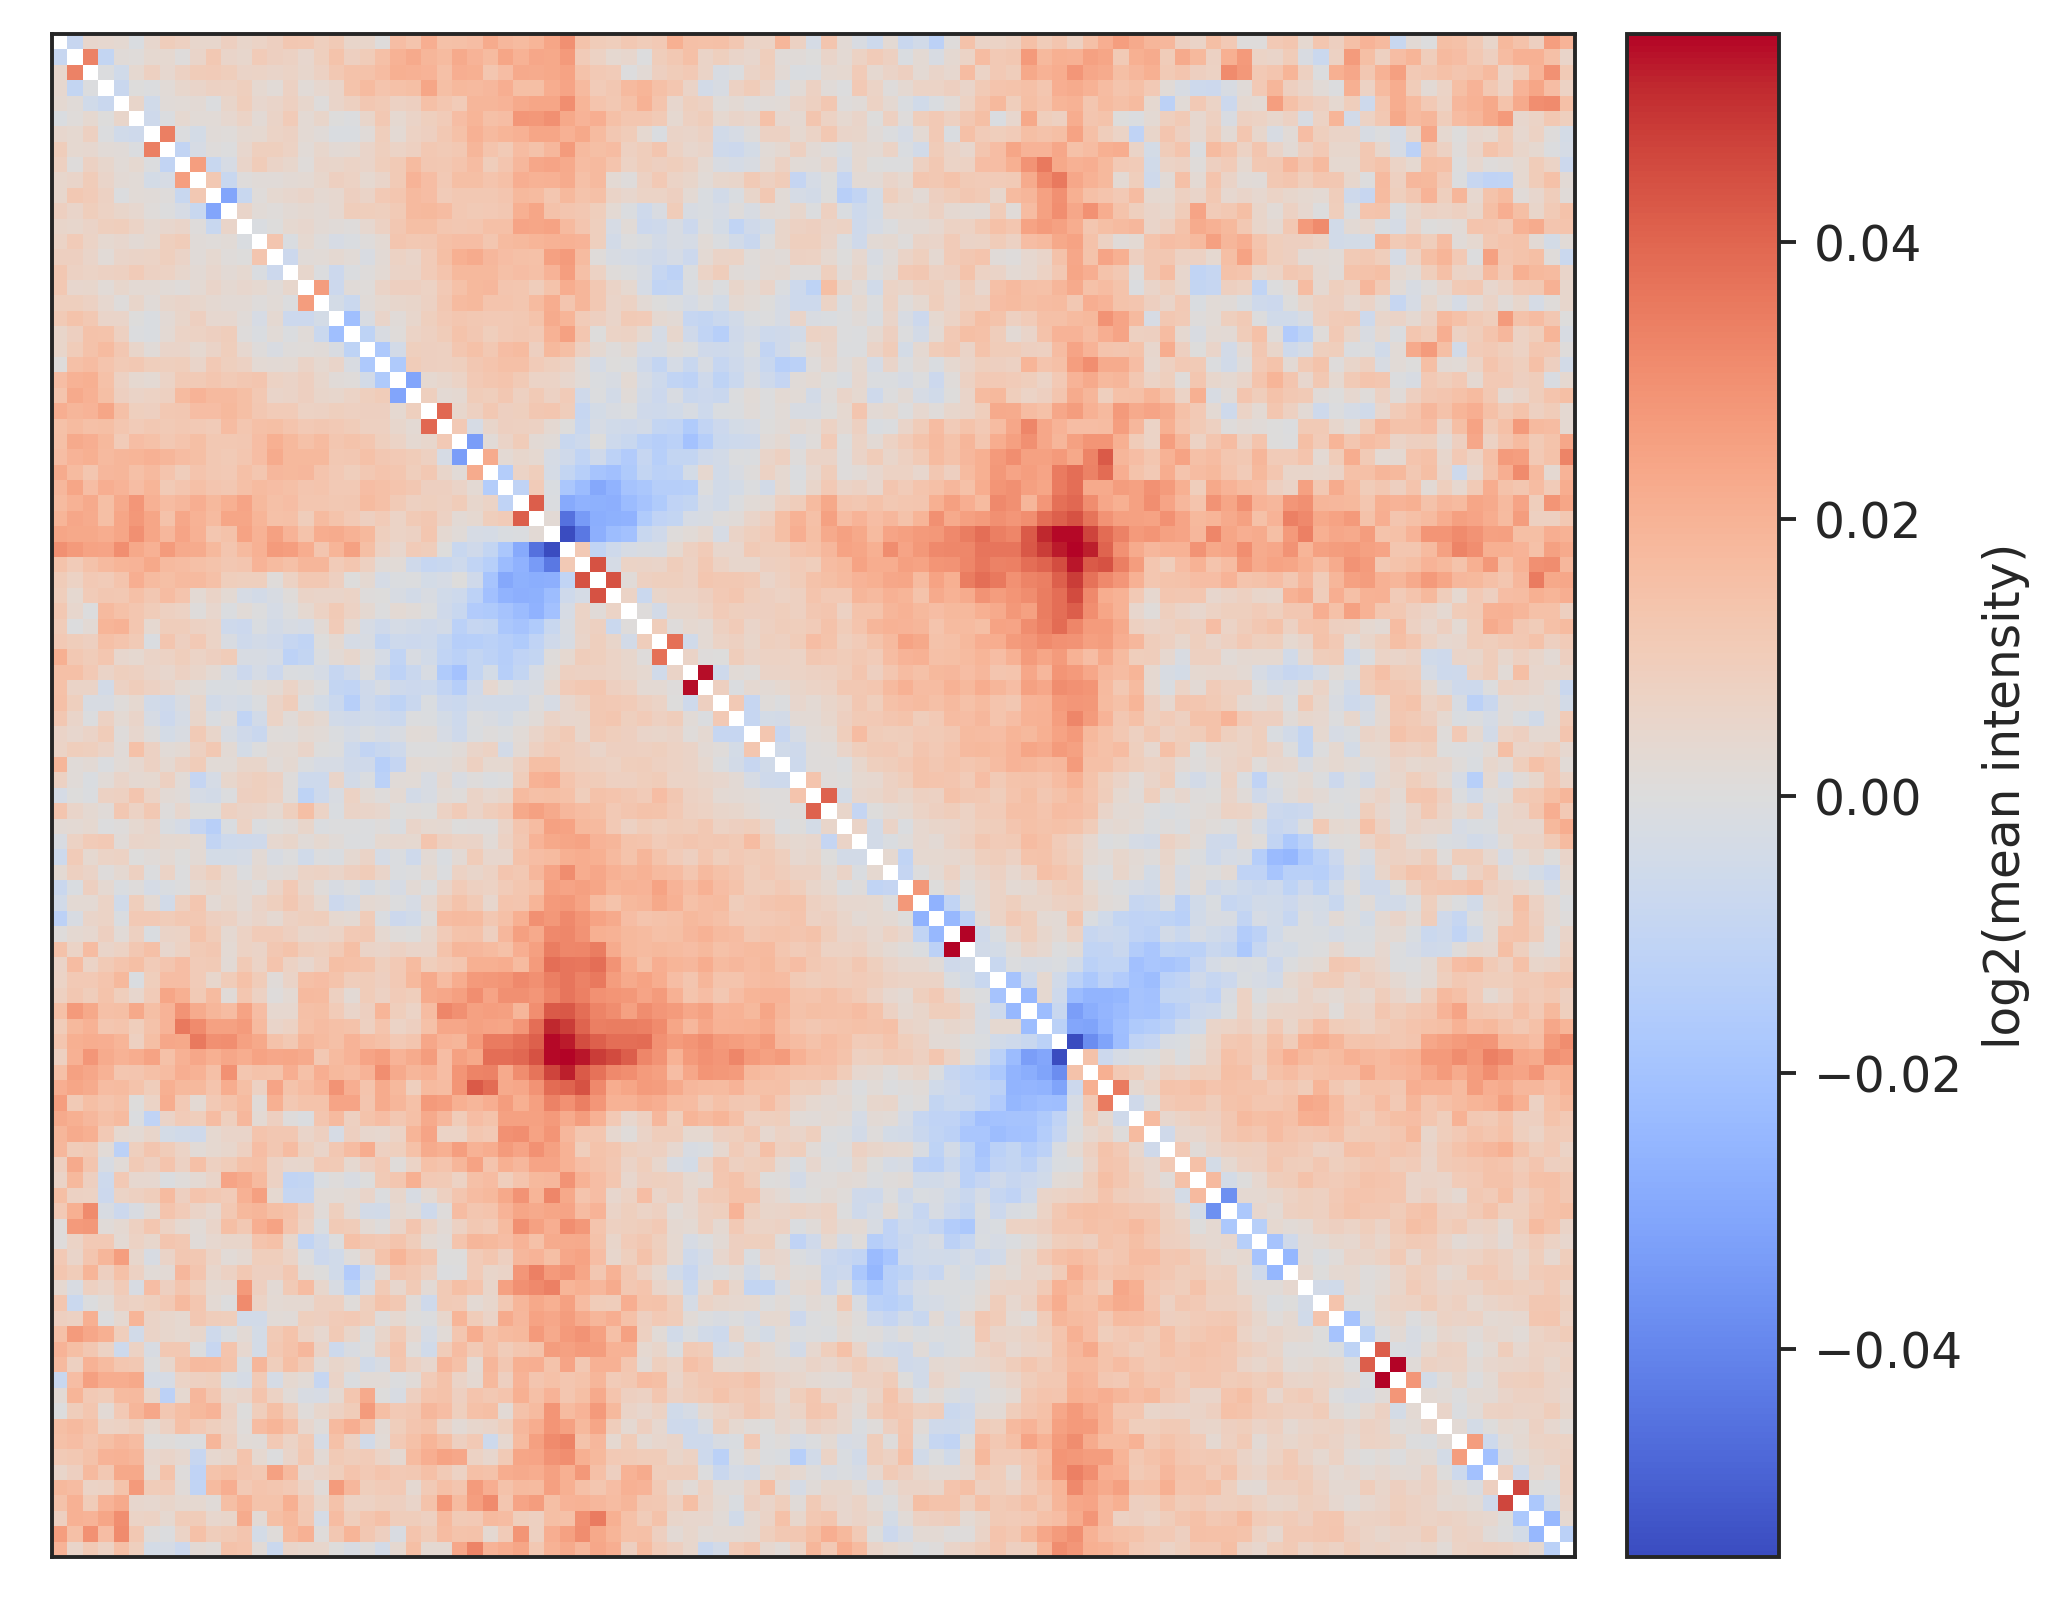

In [13]:
visualize_ratio(av_tad_old, vmin=-0.055, vmax=0.055)

In [14]:
### S6-KO/Adult average TAD

In [15]:
tad_file = merged_ko

tad_file.columns = ['chrom', 'start', 'end']

resolution = 10000
expected = [expected_ko, expected_adl]

av_tad_ko = create_average_tad_borders(tad_file, ko_clr, wt_clr, expected, resolution)

INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr8_p', 'chr8_p'): 512
INFO:coolpuppy:('chr9_p', 'chr9_p'): 561
INFO:coolpuppy:('chr3_p', 'chr3_p'): 654
INFO:coolpuppy:('chr6_p', 'chr6_p'): 663
INFO:coolpuppy:('chr4_p', 'chr4_p'): 686
INFO:coolpuppy:('chr5_p', 'chr5_p'): 670
INFO:coolpuppy:('chr7_p', 'chr7_p'): 661
INFO:coolpuppy:('chr10_p', 'chr10_p'): 535
INFO:coolpuppy:('chr1_p', 'chr1_p'): 816
INFO:coolpuppy:('chr2_p', 'chr2_p'): 763
INFO:coolpuppy:('chr19_p', 'chr19_p'): 254
INFO:coolpuppy:('chr16_p', 'chr16_p'): 416
INFO:coolpuppy:('chr17_p', 'chr17_p'): 410
INFO:coolpuppy:('chr15_p', 'chr15_p'): 446
INFO:coolpuppy:('chr13_p', 'chr13_p'): 511
INFO:coolpuppy:('chr12_p', 'chr12_p'): 470
INFO:coolpuppy:('chr14_p', 'chr14_p'): 445
INFO:coolpuppy:('chr11_p', 'chr11_p'): 548
INFO:coolpuppy:('chr18_p', 'chr18_p'): 380
INFO:coolpuppy:('chrX_p', 'chrX_p'): 664
INFO:coolpuppy:Total number of piled up windows: 11065
INFO:coolpuppy:Rescaling with rescale_fla

/tmp/ipykernel_1820280/3910377257.py:90: RuntimeWarning: invalid value encountered in divide
  ratio = stacks[0] / stacks[1]


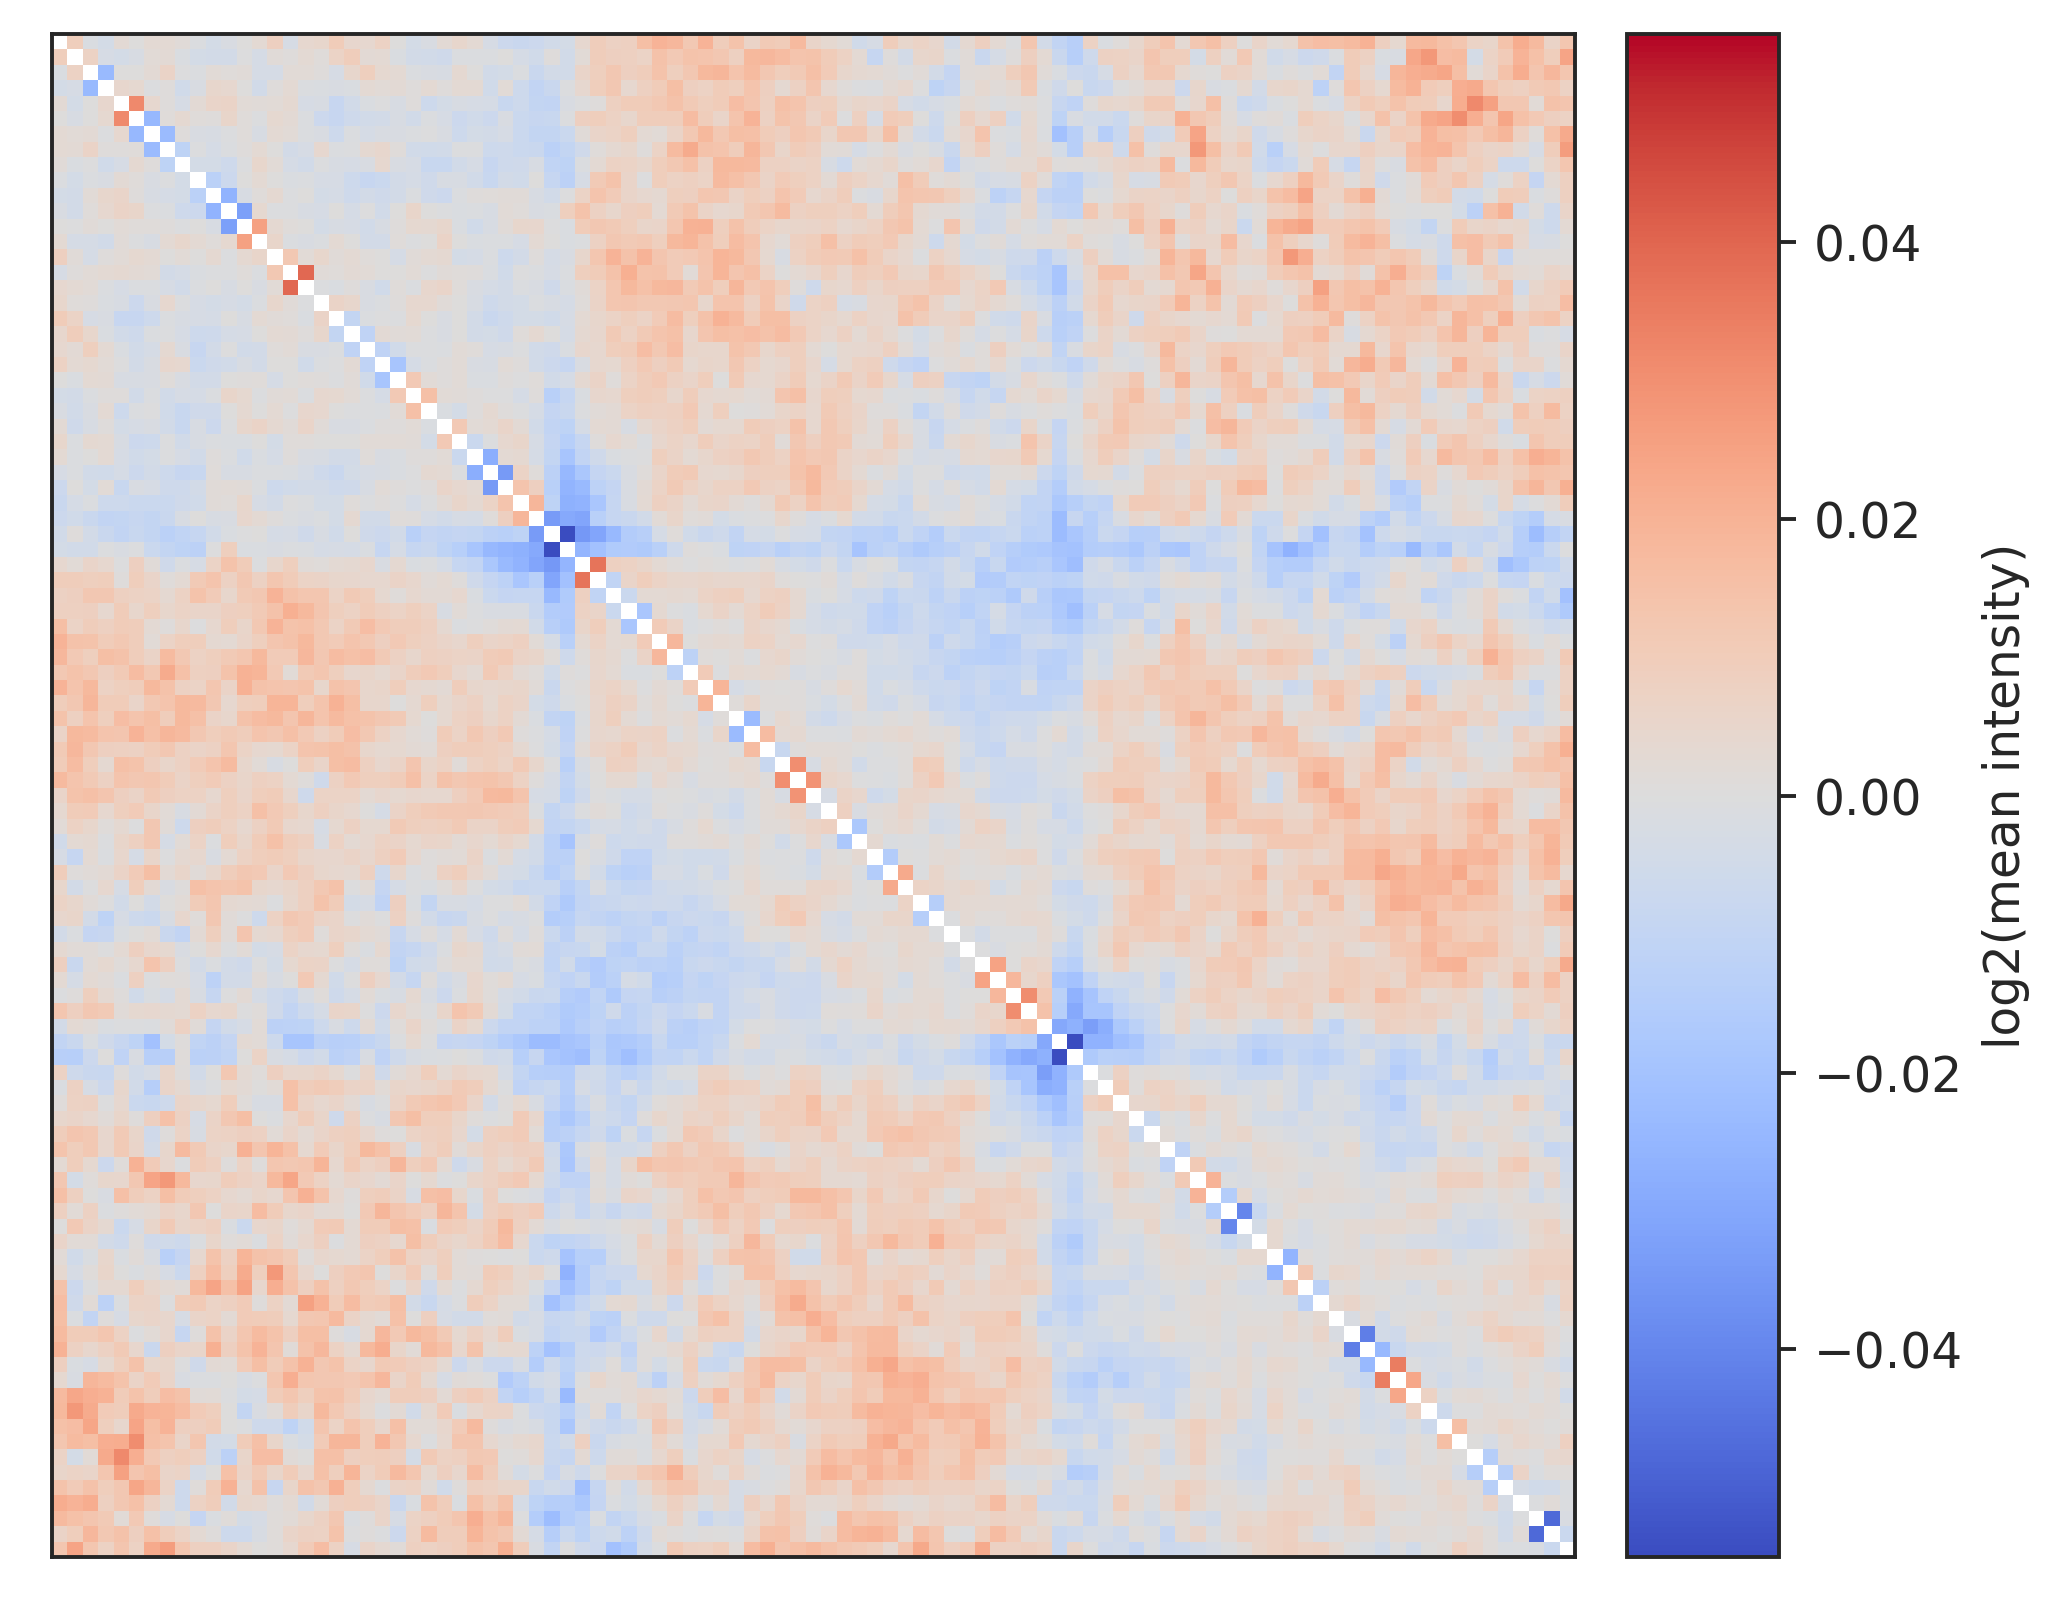

In [16]:
visualize_ratio(av_tad_ko, vmin=-0.055, vmax=0.055)

In [17]:
### Step1/Control average TAD

In [18]:
tad_file = merged_s1

tad_file.columns = ['chrom', 'start', 'end']

resolution = 10000
expected = [expected_s1, expected_con]

av_tad_s1 = create_average_tad_borders(tad_file, s1_clr, con_clr, expected, resolution)

INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr8_p', 'chr8_p'): 565
INFO:coolpuppy:('chr9_p', 'chr9_p'): 628
INFO:coolpuppy:('chr10_p', 'chr10_p'): 624
INFO:coolpuppy:('chr6_p', 'chr6_p'): 737
INFO:coolpuppy:('chr3_p', 'chr3_p'): 743
INFO:coolpuppy:('chr5_p', 'chr5_p'): 745
INFO:coolpuppy:('chr4_p', 'chr4_p'): 738
INFO:coolpuppy:('chr7_p', 'chr7_p'): 685
INFO:coolpuppy:('chr1_p', 'chr1_p'): 966
INFO:coolpuppy:('chr2_p', 'chr2_p'): 864
INFO:coolpuppy:('chr19_p', 'chr19_p'): 278
INFO:coolpuppy:('chr16_p', 'chr16_p'): 451
INFO:coolpuppy:('chr15_p', 'chr15_p'): 485
INFO:coolpuppy:('chr18_p', 'chr18_p'): 395
INFO:coolpuppy:('chr17_p', 'chr17_p'): 453
INFO:coolpuppy:('chr11_p', 'chr11_p'): 608
INFO:coolpuppy:('chr13_p', 'chr13_p'): 534
INFO:coolpuppy:('chr12_p', 'chr12_p'): 511
INFO:coolpuppy:('chr14_p', 'chr14_p'): 524
INFO:coolpuppy:('chrX_p', 'chrX_p'): 720
INFO:coolpuppy:Total number of piled up windows: 12254
INFO:coolpuppy:Rescaling with rescale_fla

/tmp/ipykernel_1820280/3910377257.py:90: RuntimeWarning: invalid value encountered in divide
  ratio = stacks[0] / stacks[1]


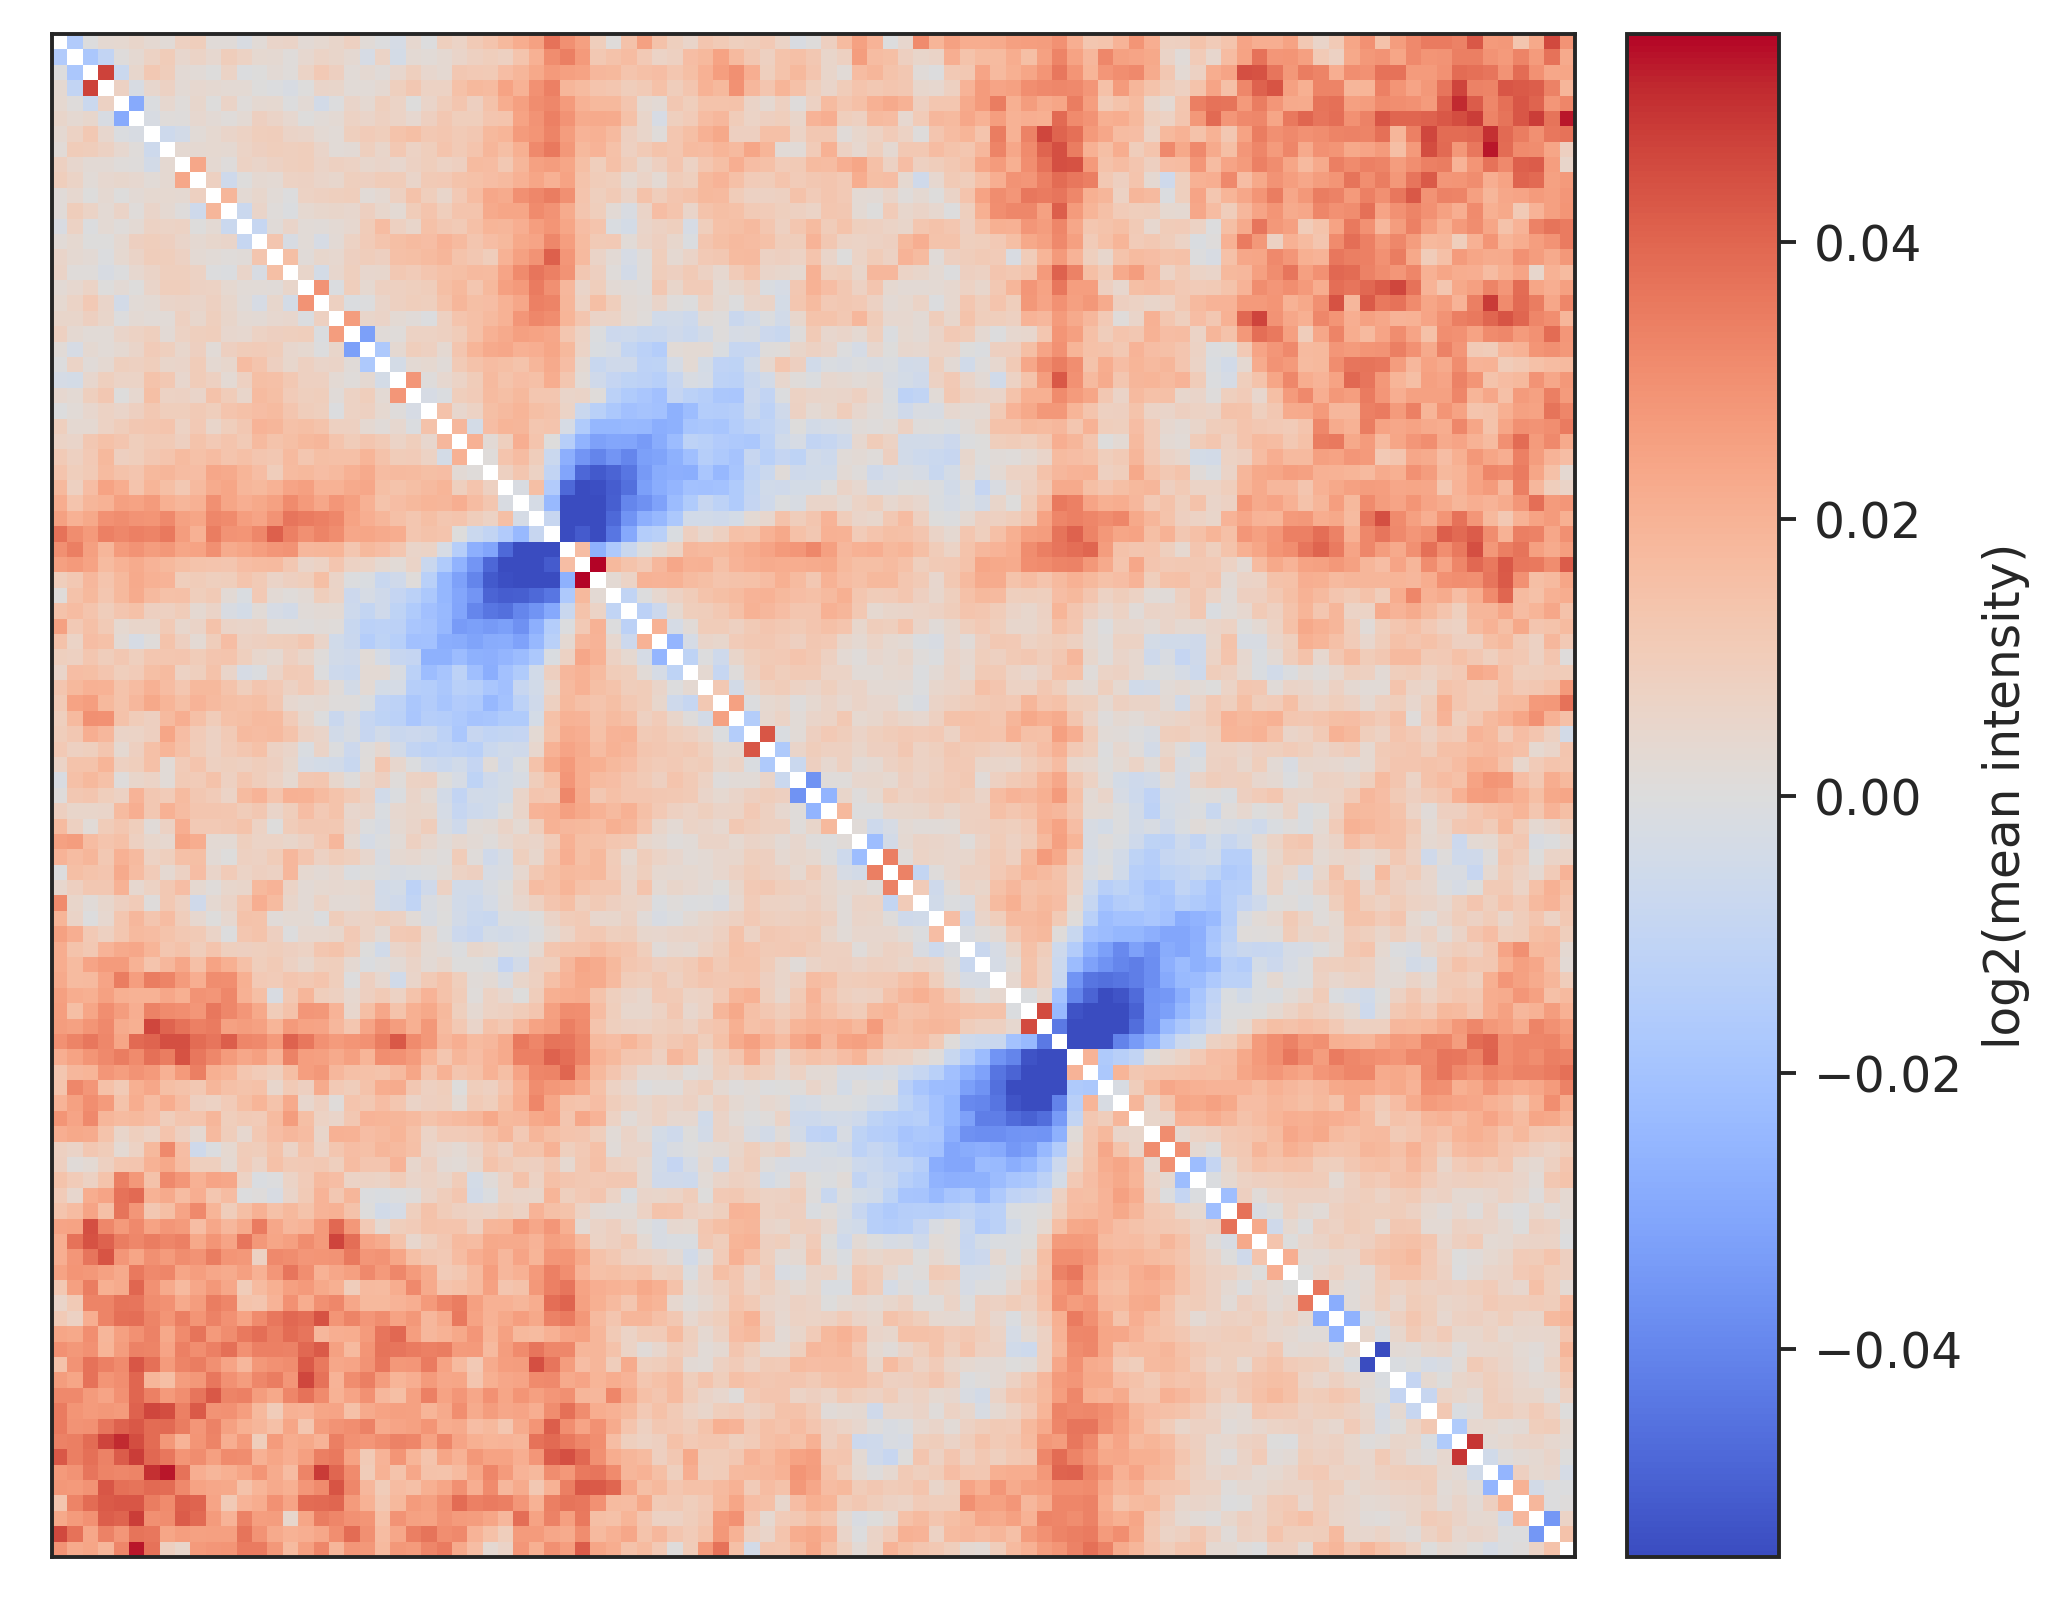

In [19]:
visualize_ratio(av_tad_s1, vmin=-0.055, vmax=0.055)

In [20]:
### Step2/Control average TAD

In [21]:
tad_file = merged_s2

tad_file.columns = ['chrom', 'start', 'end']

resolution = 10000
expected = [expected_s2, expected_con]

av_tad_s2 = create_average_tad_borders(tad_file, s2_clr, con_clr, expected, resolution)

INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr9_p', 'chr9_p'): 529
INFO:coolpuppy:('chr8_p', 'chr8_p'): 513
INFO:coolpuppy:('chr10_p', 'chr10_p'): 565
INFO:coolpuppy:('chr6_p', 'chr6_p'): 649
INFO:coolpuppy:('chr7_p', 'chr7_p'): 629
INFO:coolpuppy:('chr5_p', 'chr5_p'): 655
INFO:coolpuppy:('chr4_p', 'chr4_p'): 688
INFO:coolpuppy:('chr3_p', 'chr3_p'): 686
INFO:coolpuppy:('chr2_p', 'chr2_p'): 783
INFO:coolpuppy:('chr1_p', 'chr1_p'): 863
INFO:coolpuppy:('chr19_p', 'chr19_p'): 241
INFO:coolpuppy:('chr11_p', 'chr11_p'): 528
INFO:coolpuppy:('chr17_p', 'chr17_p'): 391
INFO:coolpuppy:('chr13_p', 'chr13_p'): 475
INFO:coolpuppy:('chr15_p', 'chr15_p'): 453
INFO:coolpuppy:('chr12_p', 'chr12_p'): 444
INFO:coolpuppy:('chr16_p', 'chr16_p'): 410
INFO:coolpuppy:('chr18_p', 'chr18_p'): 350
INFO:coolpuppy:('chr14_p', 'chr14_p'): 443
INFO:coolpuppy:('chrX_p', 'chrX_p'): 656
INFO:coolpuppy:Total number of piled up windows: 10951
INFO:coolpuppy:Rescaling with rescale_fla

/tmp/ipykernel_1820280/3910377257.py:90: RuntimeWarning: invalid value encountered in divide
  ratio = stacks[0] / stacks[1]


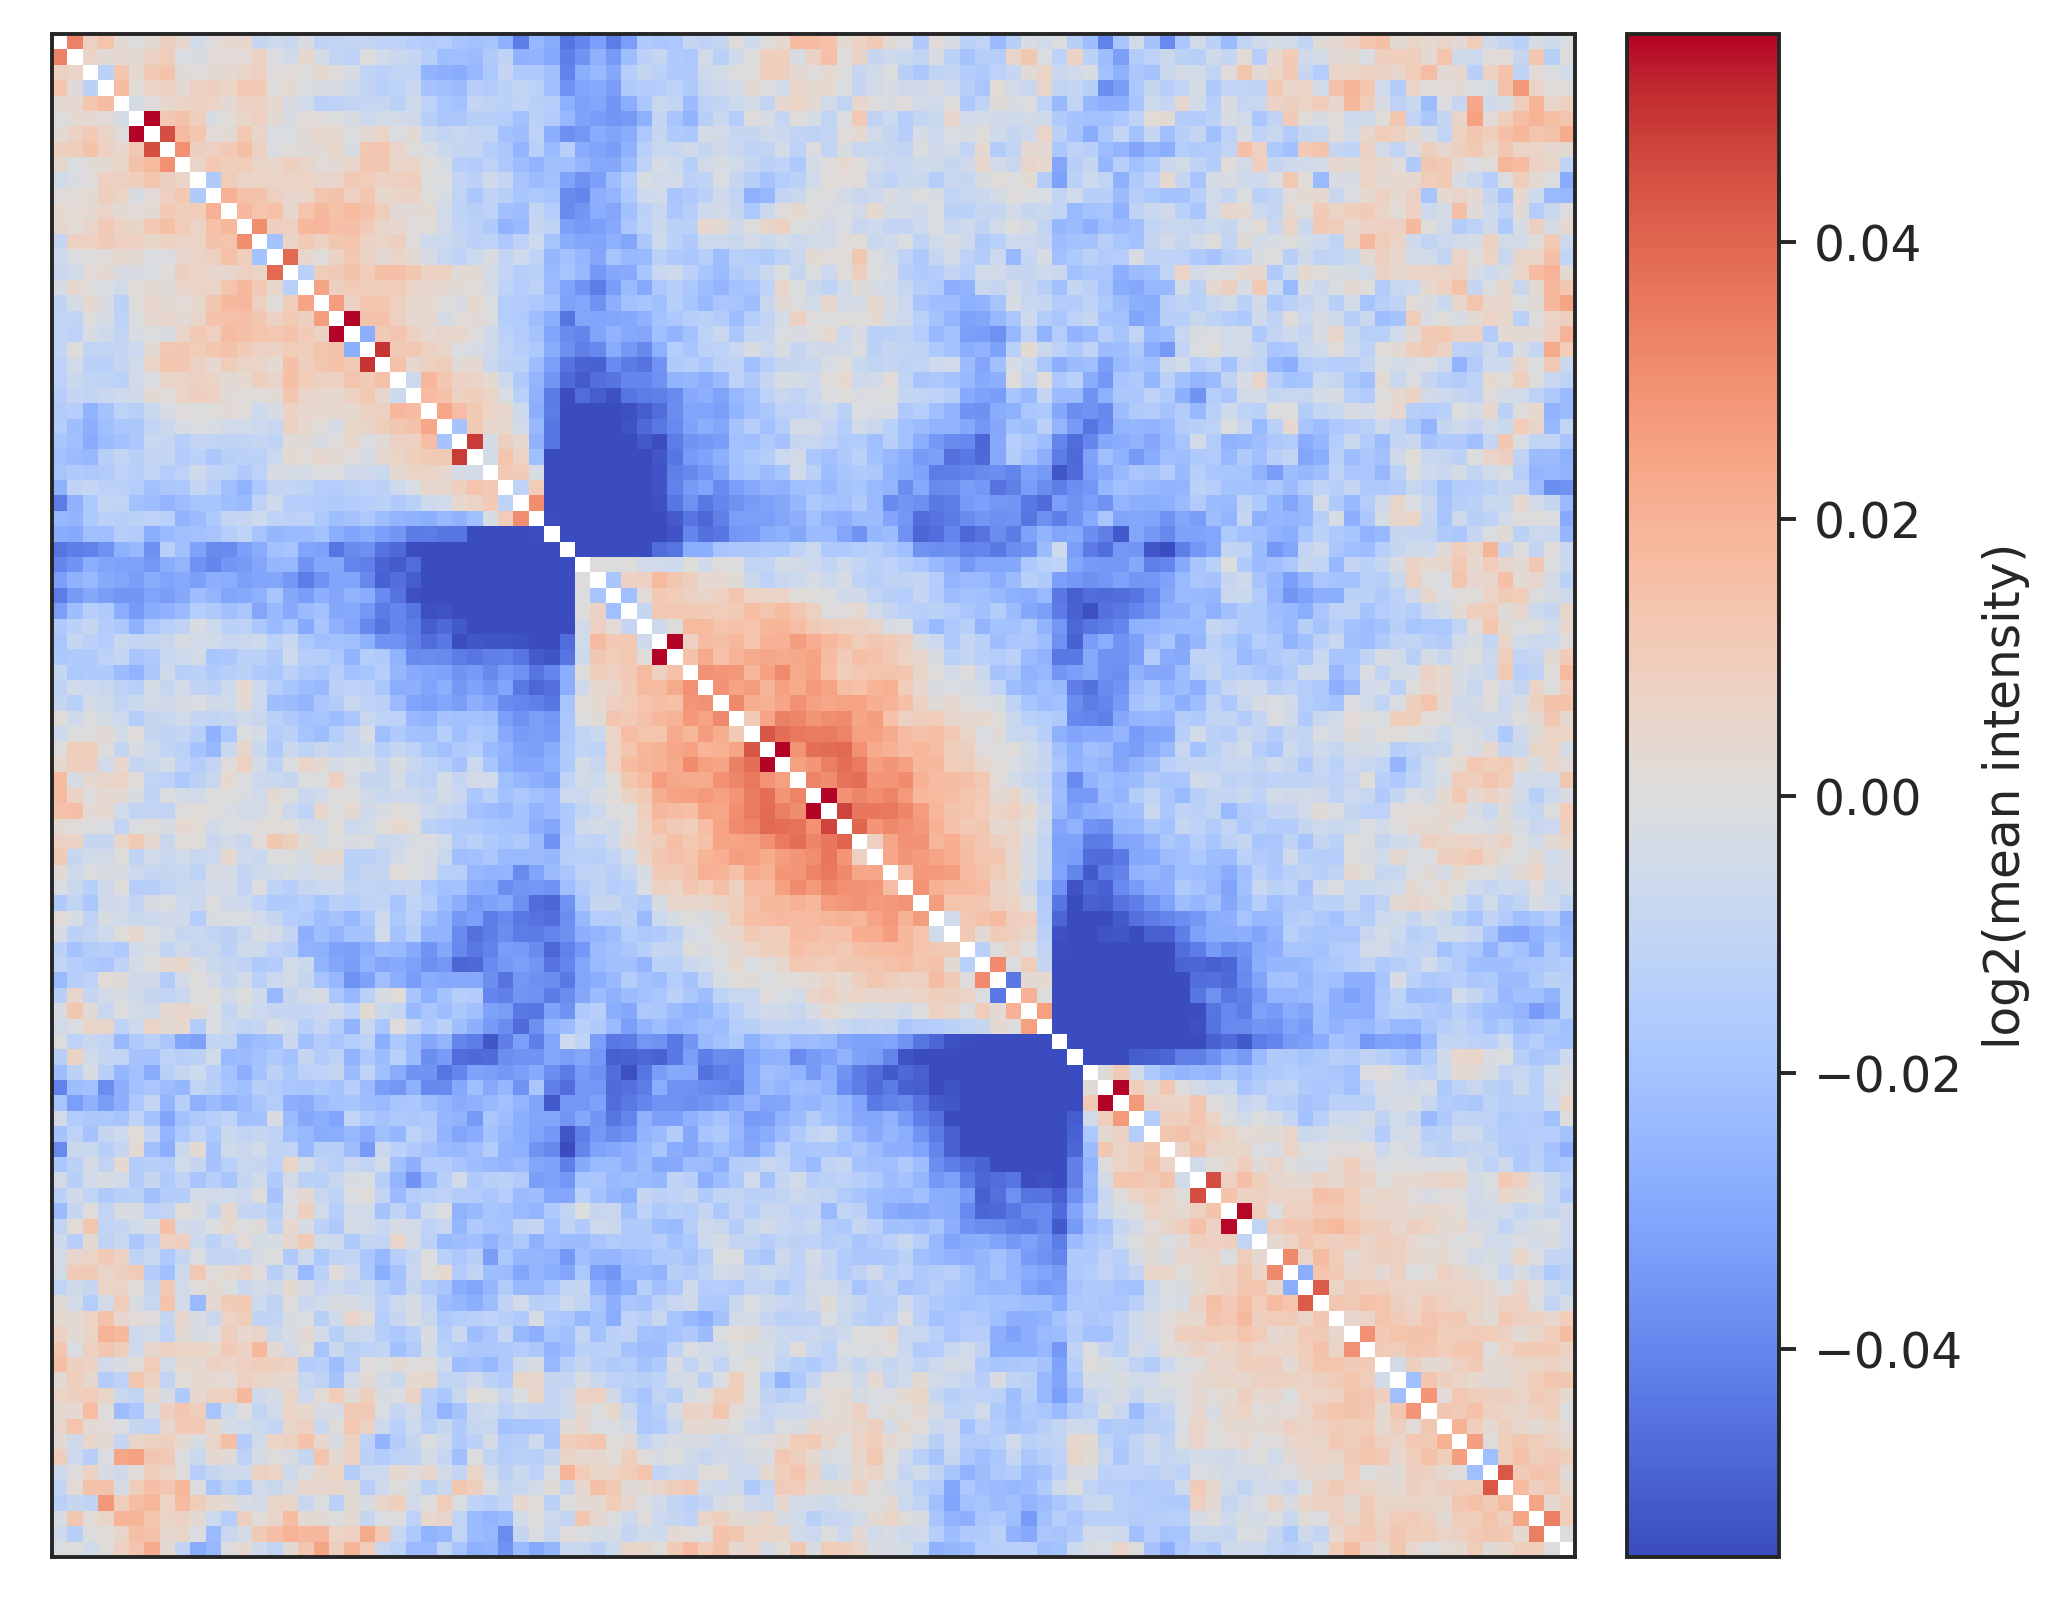

In [22]:
visualize_ratio(av_tad_s2, vmin=-0.055, vmax=0.055)

### Log2​ ratios of contact intensities, computed from the center of the bottom to the top of the central average TAD triangle in S6-KO/Adult, Old/Adult, Step1/Controo, Step2/Control comparisons

In [23]:
def compute_log_ratio(treatment_data, control_data):
    """ Computes the log2-transformed ratio of treatment over control. """
    ratio = np.divide(treatment_data, control_data, out=np.zeros_like(treatment_data), where=control_data != 0)
    ratio[ratio == np.inf] = np.nan  # Replace infinities with NaN
    log_ratio = np.log2(ratio)  # Use log2 for ratio transformation
    return log_ratio

def extract_scaling_values(log_ratio, start=(50, 50), end=(66, 33)):
    """
    Extracts values along a diagonal path or custom path for scaling.
    Args:
        log_ratio: The matrix of log-transformed ratios.
        start: Starting coordinate for the path (Ox).
        end: Ending coordinate for the path (Oy).
    Returns:
        distances: Distances from the start along the path.
        values: Log-ratio values along the path.
    """
    x, y = start
    end_x, end_y = end
    values = []
    distances = []

    distance = 0
    while x <= end_x and y >= end_y:
        if log_ratio[x, y] != np.nan:
            values.append(log_ratio[x, y])
            distances.append(distance)
        x += 1  # Move one step in the x direction
        y -= 1  # Move one step in the y direction
        distance += 1
    
    return distances, values

In [24]:
log_ratio_old_adl = compute_log_ratio(av_tad_old[0], av_tad_old[1])
log_ratio_ko_adl = compute_log_ratio(av_tad_ko[0], av_tad_ko[1])
log_ratio_s1_con = compute_log_ratio(av_tad_s1[0], av_tad_s1[1])
log_ratio_s2_con = compute_log_ratio(av_tad_s2[0], av_tad_s2[1])

distances_ko, scaling_values_ko = extract_scaling_values(log_ratio_ko_adl)
distances_old, scaling_values_old = extract_scaling_values(log_ratio_old_adl)
distances_s1, scaling_values_s1 = extract_scaling_values(log_ratio_s1_con)
distances_s2, scaling_values_s2 = extract_scaling_values(log_ratio_s2_con)

/tmp/ipykernel_1820280/3359541022.py:5: RuntimeWarning: divide by zero encountered in log2
  log_ratio = np.log2(ratio)  # Use log2 for ratio transformation


In [25]:
%load_ext rpy2.ipython

INFO:rpy2.situation:cffi mode is CFFI_MODE.ANY
INFO:rpy2.situation:R home found: /usr/lib/R
INFO:rpy2.situation:R library path: /usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server
INFO:rpy2.situation:LD_LIBRARY_PATH: /usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server
INFO:rpy2.rinterface_lib.embedded:Default options to initialize R: rpy2, --quiet, --no-save
INFO:rpy2.rinterface_lib.embedded:R is already initialized. No need to initialize.



    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    

Learn more about the underlying theory at https://ggplot2-book.org/
In addition: Warning messages:
1: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
  library ‘/usr/lib/R/site-library’ contains no packages
2: Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 
3: The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


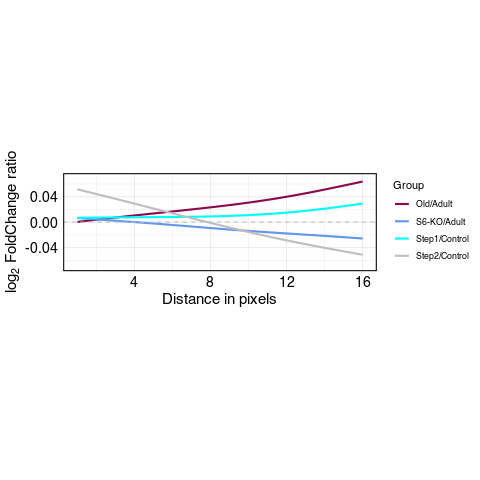

In [26]:
%%R

library(reticulate)
library(splines)
library(ggplot2)

remove_nan_inf <- function(distances, values) {
  valid_indices <- !is.na(values) & is.finite(values)
  return(list(distances[valid_indices], values[valid_indices]))
}

prepare_smooth_data <- function(distances, values, label) {
  filtered_data <- remove_nan_inf(distances, values)
  distances <- filtered_data[[1]]
  values <- filtered_data[[2]]
  
  # Sort and remove duplicates
  sorted_indices <- order(distances)
  distances <- distances[sorted_indices]
  values <- values[sorted_indices]
  
  unique_data <- unique(data.frame(Distance = distances, Log2_Ratio = values))
  
  # Interpolation
  smooth_distances <- seq(min(unique_data$Distance), max(unique_data$Distance), length.out = 300)
  smooth_values <- predict(smooth.spline(unique_data$Distance, unique_data$Log2_Ratio, spar = 0.7), smooth_distances)$y
  
  return(data.frame(Distance = smooth_distances, Log2_Ratio = smooth_values, Group = label))
}


distances          <- as.numeric( unlist(py_eval('distances_ko')) )
scaling_values_ko  <- as.numeric( unlist(py_eval('scaling_values_ko')) )
scaling_values_old <- as.numeric( unlist(py_eval('scaling_values_old')) )
scaling_values_s1 <- as.numeric( unlist(py_eval('scaling_values_s1')) )
scaling_values_s2 <- as.numeric( unlist(py_eval('scaling_values_s2')) )

df_ko <- prepare_smooth_data(distances, scaling_values_ko, "S6-KO/Adult")
df_old <- prepare_smooth_data(distances, scaling_values_old, "Old/Adult")
df_s1 <- prepare_smooth_data(distances, scaling_values_s1, "Step1/Control")
df_s2 <- prepare_smooth_data(distances, scaling_values_s2, "Step2/Control")

df <- rbind(df_ko, df_old, df_s1, df_s2)

ggplot(df, aes(x = Distance, y = Log2_Ratio, color = Group)) +
  geom_line(size = 1) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray") +
  xlab('Distance in pixels') + ylab(expression(log[2]~FoldChange~ratio)) +
  ylim(-0.07, 0.07) +
  theme_minimal() +
  scale_color_manual(values=c('deeppink4', 'cornflowerblue', 'cyan', 'grey')) +
  theme(
    axis.text = element_text(size = 14, color = "black"),
    axis.title = element_text(size = 15, color = "black"),
    #legend.position = "none",
    panel.border = element_rect(color = "black", fill = NA, size = 1),
    aspect.ratio = 1/3.2
  )

### Ratio of intensities from HiCExplorer

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.4     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


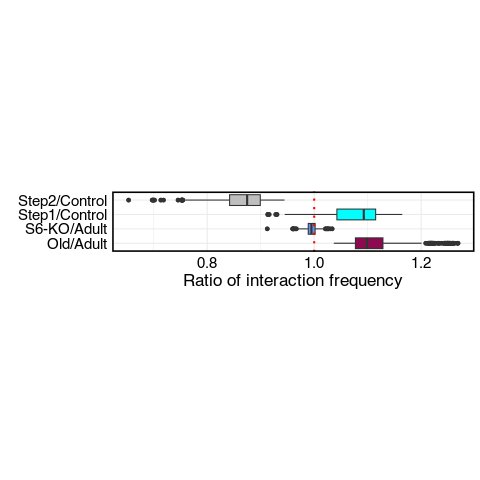

In [27]:
%%R
library(tidyverse)

np <- import("numpy")

npz_old <- np$load('/tank/projects/kashuk_sirt6_hic/avTAD/average_old_TADs_center.npz')
npz_ko <- np$load('/tank/projects/kashuk_sirt6_hic/avTAD/average_KO_TADs_center.npz')
npz_adl_old <- np$load('/tank/projects/kashuk_sirt6_hic/avTAD/average_WT_old_TADs_center.npz')
npz_adl_ko <- np$load('/tank/projects/kashuk_sirt6_hic/avTAD/average_WT_KO_TADs_center.npz')

npz_s1 <- np$load('/tank/projects/kashuk_sirt6_hic/avTAD/average_step1_TADs_center.npz')
npz_s2 <- np$load('/tank/projects/kashuk_sirt6_hic/avTAD/average_step2_TADs_center.npz')
npz_con_s1 <- np$load('/tank/projects/kashuk_sirt6_hic/avTAD/average_con_step1_TADs_center.npz')
npz_con_s2 <- np$load('/tank/projects/kashuk_sirt6_hic/avTAD/average_con_step2_TADs_center.npz')

data_old <- npz_old$f[["data"]]
data_ko <- npz_ko$f[["data"]]
data_adl_old <- npz_adl_old$f[["data"]]
data_adl_ko <- npz_adl_ko$f[["data"]]

data_s1 <- npz_s1$f[["data"]]
data_s2 <- npz_s2$f[["data"]]
data_con_s1 <- npz_con_s1$f[["data"]]
data_con_s2 <- npz_con_s2$f[["data"]]


ko_adl <- data_ko/data_adl_ko
old_adl <- data_old/data_adl_old
s1_con <- data_s1/data_con_s1
s2_con <- data_s2/data_con_s2

df <- data.frame(value = c(ko_adl, old_adl, s1_con, s2_con))
ko_adl_v <- rep(paste0('S6-KO/Adult'), times=length(ko_adl))
old_adl_v <- rep(paste0('Old/Adult'), times=length(old_adl))
s1_con_v <- rep(paste0('Step1/Control'), times=length(s1_con))
s2_con_v <- rep(paste0('Step2/Control'), times=length(s2_con))

df$type <- c(ko_adl_v, old_adl_v, s1_con_v, s2_con_v)
df$type <- factor(df$type, levels=c('Old/Adult', 'S6-KO/Adult', 'Step1/Control', 'Step2/Control'))


ggplot(df, aes(x = value, y = type)) +
  geom_boxplot(aes(fill = type), show.legend = FALSE) +
  ylab('') +
  xlab('Ratio of interaction frequency') +
  #xlim(0.6, 1.5) +
  theme_minimal() +
  geom_vline(xintercept=1, linetype='dotted', col = 'red', size=1) +
  theme(axis.text.x=element_text(color = "black",size = 15),
        axis.title.x = element_text(size = 17, colour='black'),
        axis.text.y = element_text(size = 15, colour='black'),
        panel.border = element_rect(colour = "black", fill=NA, size=1.5),
        aspect.ratio = 1/6) +
  scale_fill_manual(values=c('deeppink4', 'cornflowerblue', 'cyan', 'grey'))
